In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax
import pandas as pd

In [3]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [4]:
import solve
import aux_ as aux
import RANK
import linear
import neural_nets
import model_funcs
import plotting

# Device

In [6]:
device = aux.choose_gpu()

Avaliable devices:
cpu:0

Device = cpu:0 is choosen


# Load solutions

In [7]:
nn_path = 'output/final_nn.pkl'

In [ ]:
model = RANK.RANK_model(device)
model.load(nn_path, opt_load=False)

In [9]:
sigma_eps_u = 0.00135
sigma_eps_z = 0.02081
sigma_eps_Gamma = 0.01278

sigma_quad = {
    "sigma_eps_u" : sigma_eps_u,
    "sigma_eps_z" :  sigma_eps_z,
    "sigma_eps_Gamma" : sigma_eps_Gamma
}

N_mc = 100_000

In [10]:
linear.compute_errors(model, sigma_quad, N=100000)

                 Baseline       OccBin       Linear
----------------------------------------------------
Euler eq.        0.000410     0.298190     0.000742
NKPC             0.000567     0.000206     0.000017

ZLB binding      Baseline       OccBin       Linear
----------------------------------------------------
Euler eq.        0.001783          nan     0.005910
NKPC             0.002973          nan     0.000032


# Ergodic Distributions

In [11]:
N = 1000
T = 1000

solve.simulate(model, N, T, sigma_quad)

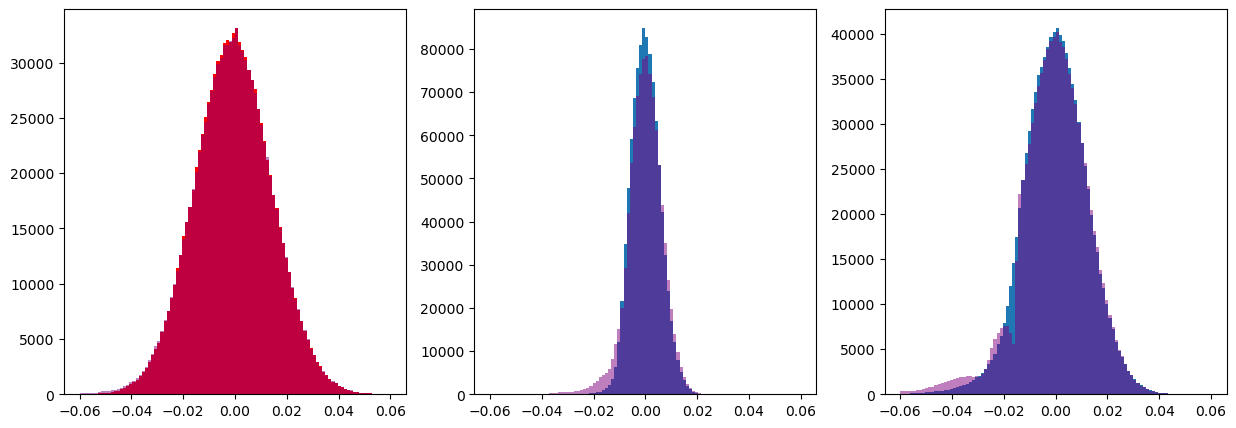

In [12]:
bins = np.linspace(-0.06, 0.06, 101)

f, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].hist(model.sim.Y_dev.flatten(), bins=bins, color='red')
#ax[0].hist(model.sim.Y_dev_lin.flatten(), bins=bins, alpha=0.5, color='green')
ax[0].hist(model.sim.Y_dev_OccBin.flatten(), bins=bins, alpha=0.5, color='purple')

ax[1].hist(model.sim.pi_dev.flatten(), bins=bins)
#ax[0].hist(model.sim.Y_dev_lin.flatten(), bins=bins, alpha=0.5, color='green')
ax[1].hist(model.sim.pi_dev_OccBin.flatten(), bins=bins, alpha=0.5, color='purple')

ax[2].hist(model.sim.i_dev.flatten(), bins=bins)
#ax[0].hist(model.sim.Y_dev_lin.flatten(), bins=bins, alpha=0.5, color='green')
ax[2].hist(model.sim.i_dev_OccBin.flatten(), bins=bins, alpha=0.5, color='purple');

# Generalized Impulse Response Functions

In [19]:
sigma_eps_u = 0.00135
sigma_eps_z = 0.05 #0.02081
sigma_eps_Gamma = 0.01278

sigma_quad = {
    "sigma_eps_u" : sigma_eps_u,
    "sigma_eps_z" :  sigma_eps_z,
    "sigma_eps_Gamma" : sigma_eps_Gamma
}

In [20]:
model.compute_IRF(sigma_quad, z_neg=True, ln_Gamma_neg=False)

In [14]:
model.compute_GIRF(sigma_quad, N_mc, z_neg=True, ln_Gamma_neg=False)

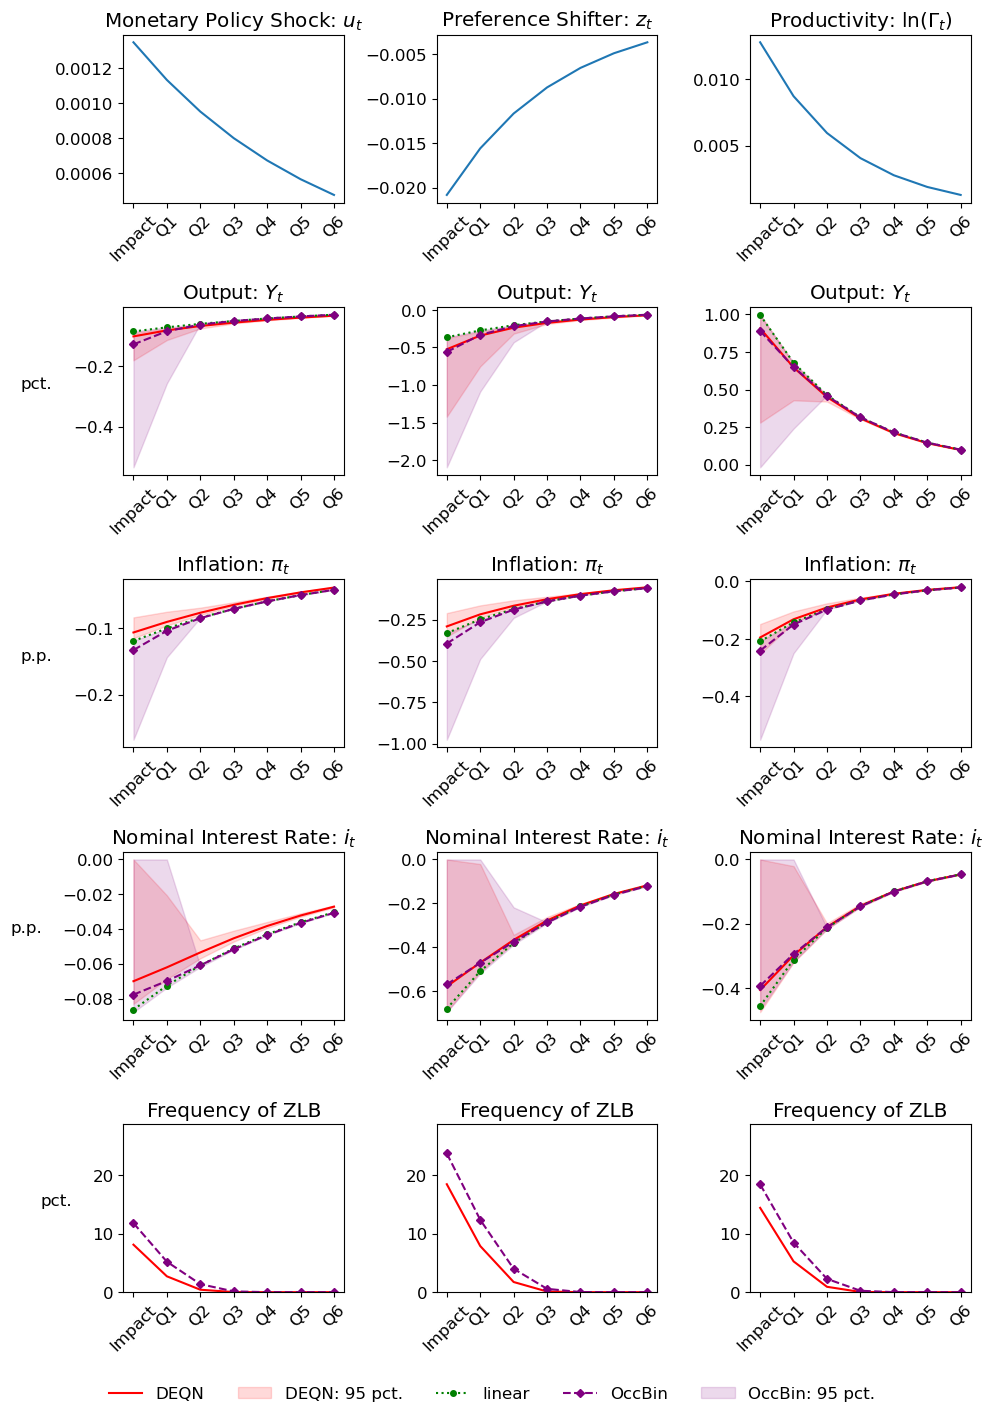

In [15]:
model.plot_GIRF(save_path='plots/Fig3_GIRFs.png')

# DEQN vs. OccBin: When does the ZLB bind?

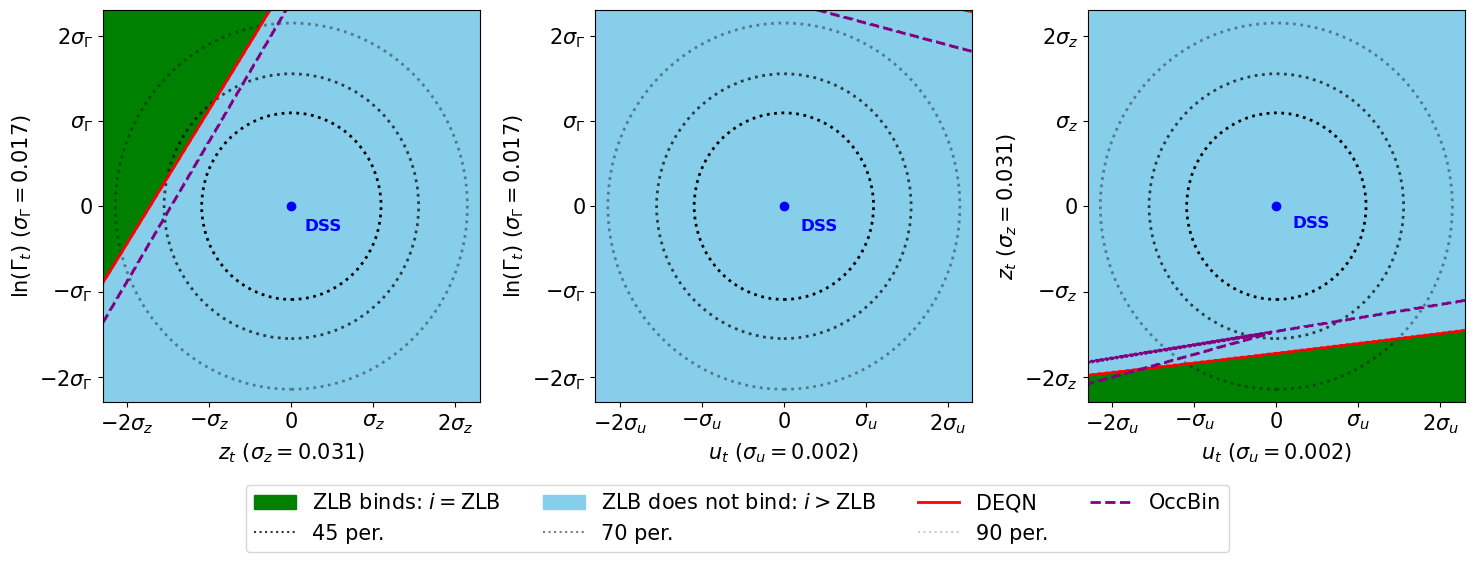

In [17]:
plotting.plot_boundaries(model, sigma_quad, N_grid=500, std_low=-2.3, std_high=2.3, save_path='plots/Fig4.png')

# Policy functions

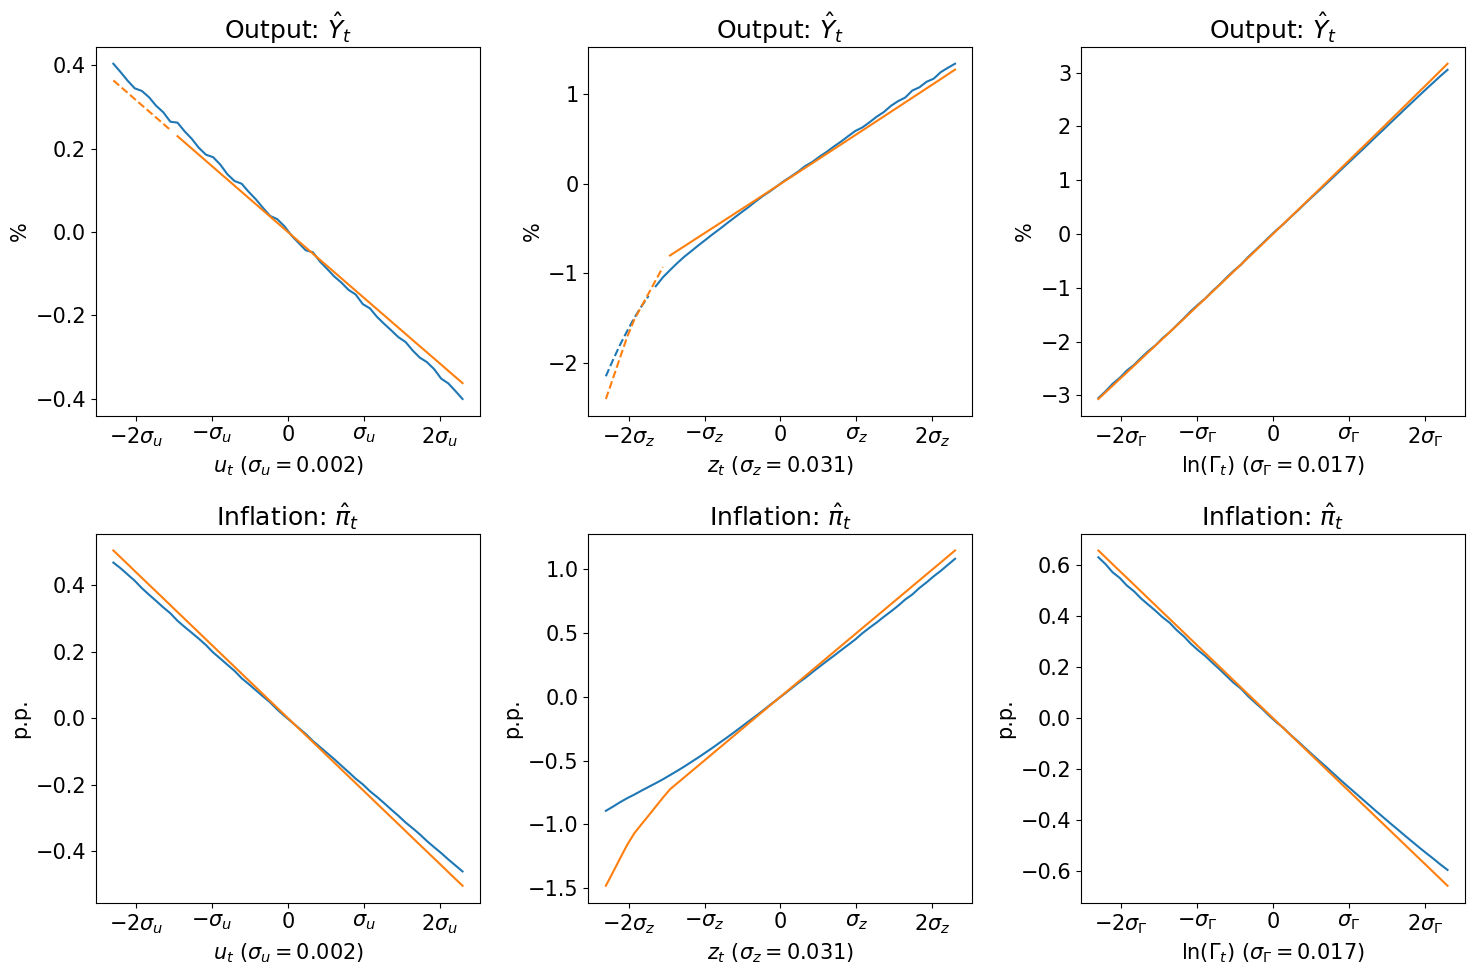

In [16]:
N_grid=50 #10000
std_low=-2.3
std_high=2.3

par = model.par

sigma_dict = sigma_quad

s_prep = jnp.linspace(std_low, std_high, N_grid)
std_u = (sigma_dict["sigma_eps_u"]/jnp.sqrt(1-par["rho_u"]**2))
std_z = (sigma_dict["sigma_eps_z"]/jnp.sqrt(1-par["rho_z"]**2))
std_ln_Gamma = (sigma_dict["sigma_eps_Gamma"]/jnp.sqrt(1-par["rho_Gamma"]**2))

Y_SSS, pi_SSS = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, jnp.zeros((1,3)), 1)
i_SSS = model_funcs.taylor_rule(model.par, Y_SSS, pi_SSS, 0.00, 0.00, 0.00, 0.00, 0.00, -0.005, 0.00)
i_DSS = model.par["i_DSS"]

u_grid = std_u*s_prep
z_grid = std_z*s_prep
ln_Gamma_grid = std_ln_Gamma*s_prep

s_u = jnp.concat([u_grid[:, None], jnp.zeros((N_grid, 2))], axis=-1)
Y_u, pi_u, i_u = neural_nets.eval_nn_dev(model.par, model.train, model.linear, model.nn, s_u, N_grid, return_i=True, ZLB=-0.005)
Y_u_OccBin, pi_u_OccBin, i_u_OccBin = linear.eval_OccBin(model, s_u, return_dev=True, return_i=True)

s_z = jnp.concat([jnp.zeros((N_grid, 1)), z_grid[:, None], jnp.zeros((N_grid, 1))], axis=-1)
Y_z, pi_z, i_z = neural_nets.eval_nn_dev(model.par, model.train, model.linear, model.nn, s_z, N_grid, return_i=True, ZLB=-0.005)
Y_z_OccBin, pi_z_OccBin, i_z_OccBin = linear.eval_OccBin(model, s_z, return_dev=True, return_i=True)

s_ln_Gamma = jnp.concat([jnp.zeros((N_grid, 2)), ln_Gamma_grid[:, None]], axis=-1)
Y_ln_Gamma, pi_ln_Gamma, i_ln_Gamma = neural_nets.eval_nn_dev(model.par, model.train, model.linear, model.nn, s_ln_Gamma, N_grid, return_i=True, ZLB=-0.005)
Y_ln_Gamma_OccBin, pi_ln_Gamma_OccBin, i_ln_Gamma_OccBin = linear.eval_OccBin(model, s_ln_Gamma, return_dev=True, return_i=True)

f,ax = plt.subplots(2,3,figsize=(15,10))

ax[0,0].plot(u_grid[jnp.isclose(i_SSS+i_u, -0.005)], 100*Y_u[jnp.isclose(i_SSS+i_u, -0.005)], color="C0", ls='--')
ax[0,0].plot(u_grid[~jnp.isclose(i_SSS+i_u, -0.005)], 100*Y_u[~jnp.isclose(i_SSS+i_u, -0.005)], color="C0")
ax[0,1].plot(z_grid[jnp.isclose(i_SSS+i_z, -0.005)], 100*Y_z[jnp.isclose(i_SSS+i_z, -0.005)], color="C0", ls='--')
ax[0,1].plot(z_grid[~jnp.isclose(i_SSS+i_z, -0.005)], 100*Y_z[~jnp.isclose(i_SSS+i_z, -0.005)], color="C0")
ax[0,2].plot(ln_Gamma_grid, 100*Y_ln_Gamma)
ax[0,0].plot(u_grid[jnp.isclose(i_DSS+i_z_OccBin, -0.005)], 100*Y_u_OccBin[jnp.isclose(i_DSS+i_z_OccBin, -0.005)], color="C1", ls='--')
ax[0,0].plot(u_grid[~jnp.isclose(i_DSS+i_z_OccBin, -0.005)], 100*Y_u_OccBin[~jnp.isclose(i_DSS+i_z_OccBin, -0.005)], color="C1")
ax[0,1].plot(z_grid[jnp.isclose(i_DSS+i_z_OccBin, -0.005)], 100*Y_z_OccBin[jnp.isclose(i_DSS+i_z_OccBin, -0.005)], color="C1", ls='--')
ax[0,1].plot(z_grid[~jnp.isclose(i_DSS+i_z_OccBin, -0.005)], 100*Y_z_OccBin[~jnp.isclose(i_DSS+i_z_OccBin, -0.005)], color="C1")

ax[0,2].plot(ln_Gamma_grid, 100*Y_ln_Gamma_OccBin)

ax[1,0].plot(u_grid, 100*pi_u)
ax[1,1].plot(z_grid, 100*pi_z)
ax[1,2].plot(ln_Gamma_grid, 100*pi_ln_Gamma)
ax[1,0].plot(u_grid, 100*pi_u_OccBin)
ax[1,1].plot(z_grid, 100*pi_z_OccBin)
ax[1,2].plot(ln_Gamma_grid, 100*pi_ln_Gamma_OccBin)

def set_std_ticks(ax, std_val, symbol, sigma_label, axis='x', decimals=3):
    ticks = [-2*std_val, -std_val, 0, std_val, 2*std_val]
    labels = [
        rf'$-2\sigma_{{{sigma_label}}}$',
        rf'$-\sigma_{{{sigma_label}}}$',
        '0',
        rf'$\sigma_{{{sigma_label}}}$',
        rf'$2\sigma_{{{sigma_label}}}$'
    ]
    if axis == 'x':
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels)
        ax.set_xlabel(rf'${symbol}$ $(\sigma_{{{sigma_label}}}={std_val:.3f})$')
    else:
        ax.set_yticks(ticks)
        ax.set_yticklabels(labels)
        ax.set_ylabel(rf'${symbol}$ $(\sigma_{{{sigma_label}}}={std_val:.3f})$')

std_u_val        = float(std_u)
std_z_val        = float(std_z)
std_ln_Gamma_val = float(std_ln_Gamma)

for i in range(2):
    set_std_ticks(ax[i,0], std_u_val,        'u_t',            'u',        axis='x')

    set_std_ticks(ax[i,1], std_z_val,        'z_t',            'z',        axis='x')

    set_std_ticks(ax[i,2], std_ln_Gamma_val,        '\ln(\Gamma_t)',            r'\Gamma',        axis='x')

for i in range(3):
    ax[0,i].set_ylabel('%')
    ax[0,i].set_title(r'Output: $\hat{Y}_t$')

for i in range(3):
    ax[1,i].set_ylabel('p.p.')
    ax[1,i].set_title(r'Inflation: $\hat{\pi}_t$')

f.tight_layout()

# Statistics of the ZLB

In [17]:
N = 500
T = 100000

solve.simulate(model, N, T, sigma_quad, ZLB=-0.005, do_OccBin=True, init_SSS=False)

### Conditional probabilities

In [18]:
ZLB_dummy = model.sim.i <= -0.005 + 1e-5
ZLB_dummy_OccBin = model.sim.i_OccBin <= -0.005 + 1e-5
p_ZLB = jnp.mean(ZLB_dummy).item()
p_ZLB_OccBin = jnp.mean(ZLB_dummy_OccBin).item()

In [36]:
print(f'ZLB frequency (DEQN):\t\t{p_ZLB:.4f}')
print(f'ZLB frequency (OccBin):\t\t{p_ZLB_OccBin:.4f}')
# print(f'(i<=0.0)-frequency (DEQN):\t{jnp.mean(model.sim.i <= 0.01):.4f}')
# print(f'(i<=0.0)-frequency (OccBin):\t{jnp.mean(model.sim.i_OccBin <= 0.01):.4f}')

ZLB frequency (DEQN):		0.0739
ZLB frequency (OccBin):		0.1022


In [19]:
ZLB_dummies_df = pd.DataFrame(ZLB_dummy)
ZLB_dummies_df_OccBin = pd.DataFrame(ZLB_dummy_OccBin)

In [20]:
# Tau = 8
# Corrs = np.zeros(Tau) + np.nan
# Corrs_OccBin = np.zeros(Tau) + np.nan

# for i_tau, tau in enumerate(range(1,Tau+1)):
#     Corrs[i_tau] = ZLB_dummies_df.apply(lambda col: col.autocorr(lag=tau), axis=0).mean().item()
#     Corrs_OccBin[i_tau] = ZLB_dummies_df_OccBin.apply(lambda col: col.autocorr(lag=tau), axis=0).mean().item()

### Correlations

In [21]:
def state_zlb_corr(state_df, zlb_df, lags=[-4, 0, 4]):
    results = {}
    for lag in lags:
        shifted = state_df.shift(lag)
        results[lag] = shifted.apply(lambda col: col.corr(zlb_df[col.name])).mean()
    return pd.Series(results)

In [22]:
u = pd.DataFrame(model.sim.u)
z =  pd.DataFrame(model.sim.z)
ln_Gamma =  pd.DataFrame(model.sim.ln_Gamma)

ZLB_u_corr = state_zlb_corr(u, ZLB_dummies_df) #u.apply(lambda col: col.corr(ZLB_dummies_df[col.name])).mean()
ZLB_z_corr = state_zlb_corr(z, ZLB_dummies_df) #z.apply(lambda col: col.corr(ZLB_dummies_df[col.name])).mean()
ZLB_ln_Gamma_corr = state_zlb_corr(ln_Gamma, ZLB_dummies_df) # ln_Gamma.apply(lambda col: col.corr(ZLB_dummies_df[col.name])).mean()

ZLB_u_corr_OccBin = state_zlb_corr(u, ZLB_dummies_df_OccBin)
ZLB_z_corr_OccBin = state_zlb_corr(z, ZLB_dummies_df_OccBin)
ZLB_ln_Gamma_corr_OccBin = state_zlb_corr(ln_Gamma, ZLB_dummies_df_OccBin) 

KeyboardInterrupt: 

In [ ]:
print(ZLB_u_corr)
print(ZLB_z_corr)
print(ZLB_ln_Gamma_corr)
print(ZLB_u_corr_OccBin)
print(ZLB_z_corr_OccBin)
print(ZLB_ln_Gamma_corr_OccBin)

-4    0.026057
 0    0.052289
 4    0.025735
dtype: float64
-4   -0.140933
 0   -0.448957
 4   -0.140983
dtype: float64
-4    0.061599
 0    0.285805
 4    0.061916
dtype: float64
-4    0.050172
 0    0.100749
 4    0.049930
dtype: float64
-4   -0.155304
 0   -0.494669
 4   -0.155322
dtype: float64
-4    0.065064
 0    0.301841
 4    0.065396
dtype: float64


In [ ]:
print(ZLB_dummy.mean())
print(ZLB_dummy_OccBin.mean())

0.07390168
0.10223788


In [ ]:
from itertools import groupby

def zlb_duration_stats(col):
    runs = [len(list(g)) for k, g in groupby(col) if k == 1]
    if not runs:
        return pd.Series({
            "mean": 0, "median": 0, "p25": 0, "p75": 0,
            "p90": 0, "min": 0, "max": 0
        })
    return pd.Series({
        "mean":   np.mean(runs),
        "median": np.median(runs),
        "p25":    np.percentile(runs, 25),
        "p75":    np.percentile(runs, 75),
        "p90":    np.percentile(runs, 90),
        "min":    np.min(runs),
        "max":    np.max(runs)
    })

In [ ]:
stats = ZLB_dummies_df.apply(zlb_duration_stats, axis=0).T.mean()
print(stats)

stats = ZLB_dummies_df_OccBin.apply(zlb_duration_stats, axis=0).T.mean()
print(stats)

mean       1.853032
median     1.000000
p25        1.000000
p75        2.000000
p90        3.907000
min        1.000000
max       14.342000
dtype: float64
mean       2.000313
median     1.000000
p25        1.000000
p75        2.036000
p90        4.000000
min        1.000000
max       16.568000
dtype: float64


In [ ]:
def zlb_durations(df):
    return [
        len(list(g))
        for col in df.columns
        for k, g in groupby(df[col])
        if k == 1
    ]

all_zlb_spells = zlb_durations(ZLB_dummies_df)
all_zlb_spells_OccBin = zlb_durations(ZLB_dummies_df_OccBin)

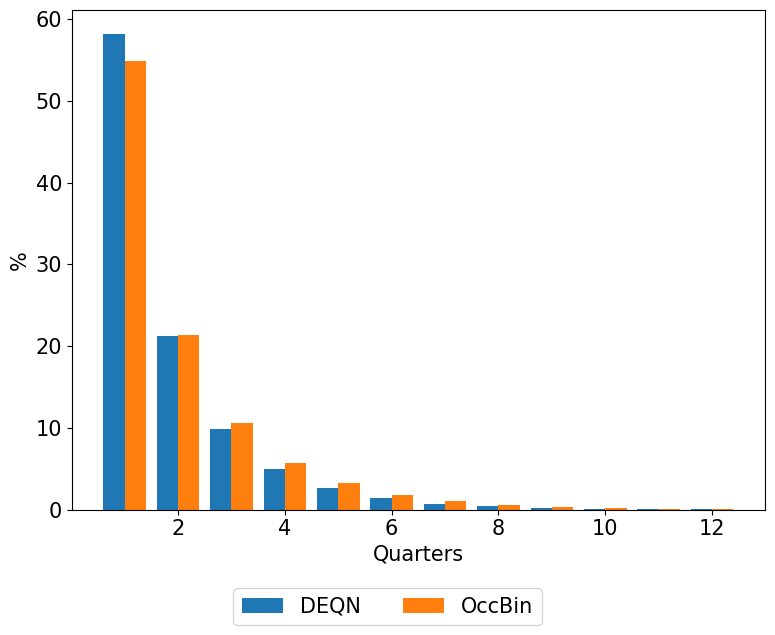

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))

bins = np.arange(0.5, 13.5, 1)

ax.hist(
    [all_zlb_spells, all_zlb_spells_OccBin],
    bins=bins,
    weights=[
        [100/len(all_zlb_spells)] * len(all_zlb_spells),
        [100/len(all_zlb_spells_OccBin)] * len(all_zlb_spells_OccBin)
    ],
    label=['DEQN', 'OccBin']
)

ax.set_ylabel('%')
ax.set_xlabel('Quarters')

# bins2 = np.linspace(
#     min(100*model.sim.i.min(), 100*model.sim.i_OccBin.min()),
#     max(100*model.sim.i.max(), 100*model.sim.i_OccBin.max()),
#     100
# )

# ax[1].hist(100*model.sim.i.flatten(), bins=bins2, density=True, label='DEQN')
# ax[1].hist(100*model.sim.i_OccBin.flatten(), bins=bins2, density=True, alpha=0.5, label='OccBin')
# ax[1].set_xlim(right=5)
# ax[1].set_xlabel('%')
# ax[1].set_xticks([-0.5, 0, 1, 2, 3, 4, 5])
# ax[1].set_title(r'Ergodic Distribution of $i_t$')

f.legend(loc='lower center', ncols=2, bbox_to_anchor=(0.5, -0.08))

f.tight_layout()

f.savefig('plots/Fig5.png', bbox_inches='tight')

In [ ]:
print(jnp.mean(jnp.array(all_zlb_spells)))
print(jnp.mean(jnp.array(all_zlb_spells_OccBin)))

1.8529972
2.000285


In [ ]:
print(jnp.mean(jnp.array(all_zlb_spells) == 6))
print(jnp.mean(jnp.array(all_zlb_spells_OccBin) == 6))

0.01397113
0.018447062


In [ ]:
zlb_1more = []
zlb_1more_OccBin = []

Tau = 12
for tau in range(1, 1+Tau):
    P_num = jnp.mean(jnp.array(all_zlb_spells) == tau + 1)
    P_denom = jnp.mean(jnp.array(all_zlb_spells) == tau)
    zlb_1more.append(P_num/P_denom)

    P_num_OccBin = jnp.mean(jnp.array(all_zlb_spells_OccBin) == tau + 1)
    P_denom_OccBin = jnp.mean(jnp.array(all_zlb_spells_OccBin) == tau)
    zlb_1more_OccBin.append(P_num_OccBin/P_denom_OccBin)

In [ ]:
zlb_1more

[Array(0.36494896, dtype=float32),
 Array(0.4648278, dtype=float32),
 Array(0.5092136, dtype=float32),
 Array(0.5223879, dtype=float32),
 Array(0.53196365, dtype=float32),
 Array(0.5367911, dtype=float32),
 Array(0.5412906, dtype=float32),
 Array(0.54095113, dtype=float32),
 Array(0.5366522, dtype=float32),
 Array(0.5242553, dtype=float32),
 Array(0.58847404, dtype=float32),
 Array(0.54206896, dtype=float32)]

In [ ]:
zlb_1more_OccBin

[Array(0.3882049, dtype=float32),
 Array(0.49438387, dtype=float32),
 Array(0.54269487, dtype=float32),
 Array(0.560176, dtype=float32),
 Array(0.5759753, dtype=float32),
 Array(0.5638377, dtype=float32),
 Array(0.5887664, dtype=float32),
 Array(0.58076674, dtype=float32),
 Array(0.56815934, dtype=float32),
 Array(0.58617353, dtype=float32),
 Array(0.6098447, dtype=float32),
 Array(0.54983747, dtype=float32)]

### Conditional distributions

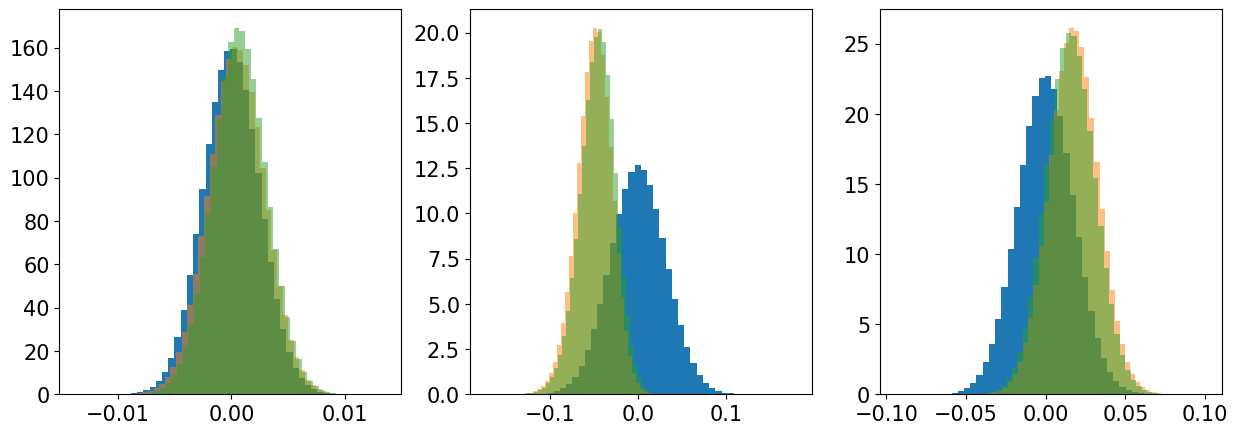

In [ ]:
f, ax = plt.subplots(1,3,figsize=(15,5))

for i, s in zip(range(3), [model.sim.u, model.sim.z, model.sim.ln_Gamma]):
    ax[i].hist(s.flatten(), density=True, bins=50)
    ax[i].hist(s[ZLB_dummy].flatten(), density=True, bins=50, alpha=0.5)
    ax[i].hist(s[ZLB_dummy_OccBin].flatten(), density=True, bins=50, alpha=0.5)

In [ ]:
def zlb_min_spell(df, min_spell=4):
    def col_dummy(col):
        rolling_sum = col.rolling(min_spell).sum()
        return (rolling_sum == min_spell).astype(int)
    return df.apply(col_dummy, axis=0)

ZLB_4spell = zlb_min_spell(ZLB_dummies_df).to_numpy().astype(bool)
ZLB_4spell_OccBin = zlb_min_spell(ZLB_dummies_df_OccBin).to_numpy().astype(bool)



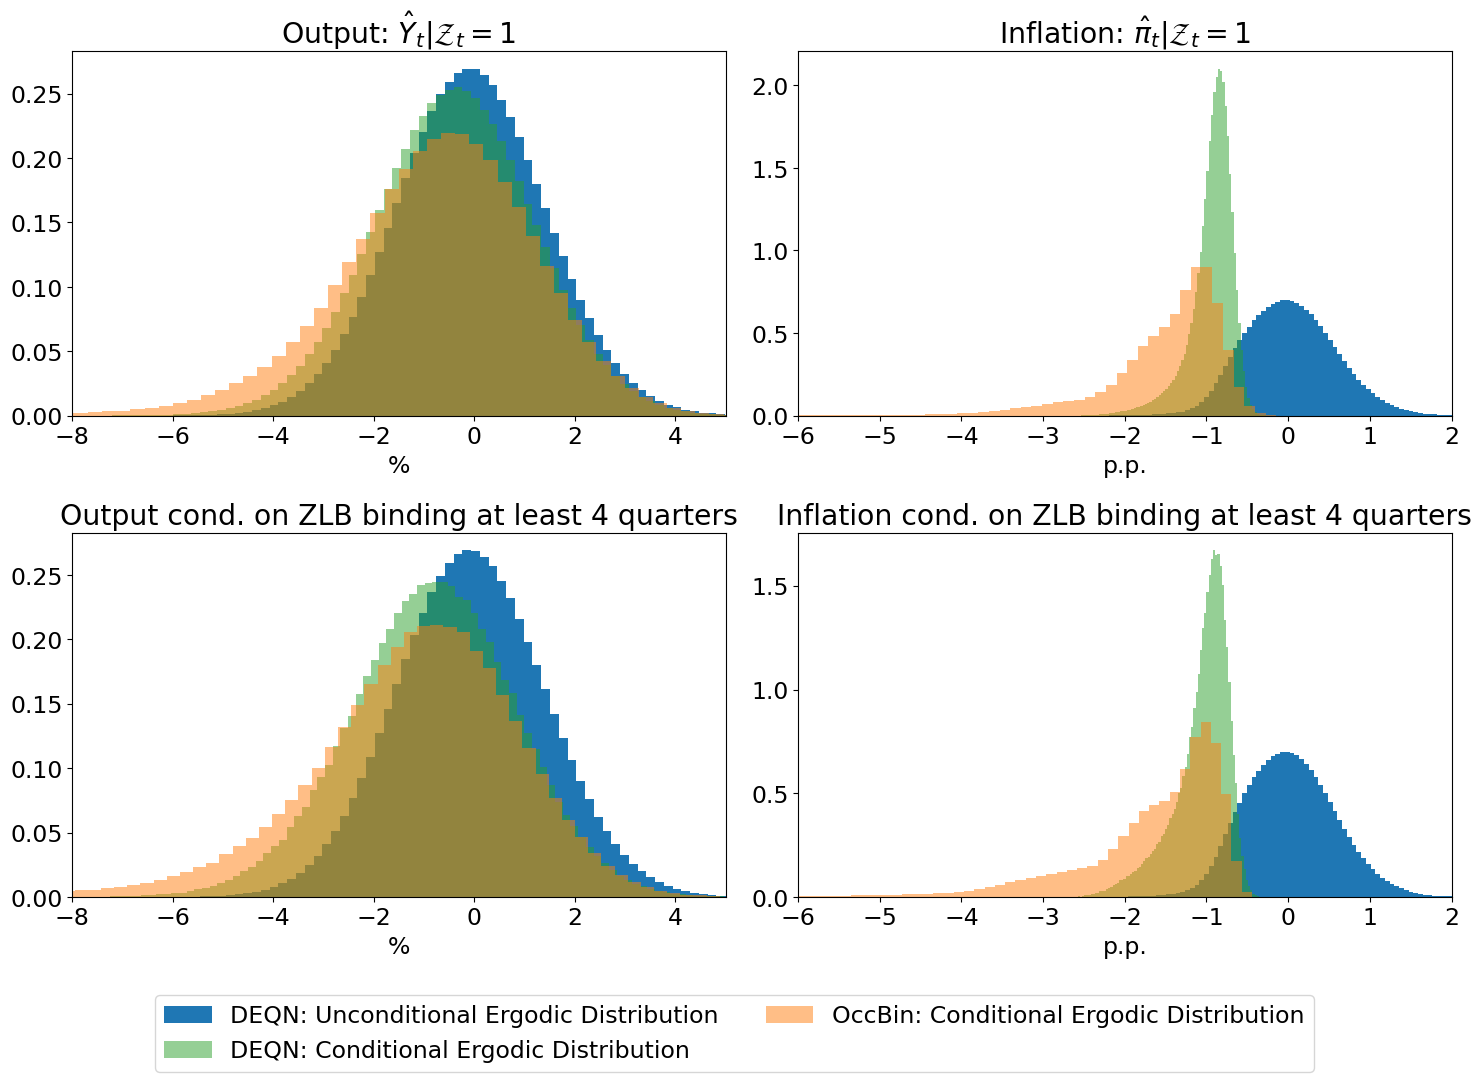

In [ ]:
plt.rcParams.update({'font.size': 17})

f, ax = plt.subplots(2,2,figsize=(15,10))

ax[0,0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True, color='C0', label='DEQN: Unconditional Ergodic Distribution')
ax[0,0].hist(100*model.sim.Y_dev[ZLB_dummy].flatten(), bins=100, density=True, color='C2', alpha=0.5, label='DEQN: Conditional Ergodic Distribution')
ax[0,0].hist(100*model.sim.Y_dev_OccBin[ZLB_dummy].flatten(), bins=100, density=True, color='C1', alpha=0.5, label='OccBin: Conditional Ergodic Distribution')

ax[0,1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True, color='C0')
ax[0,1].hist(100*model.sim.pi_dev[ZLB_dummy].flatten(), bins=100, density=True, color='C2', alpha=0.5)
ax[0,1].hist(100*model.sim.pi_dev_OccBin[ZLB_dummy].flatten(), bins=100, density=True, color='C1', alpha=0.5)

ax[1,0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True, color='C0')
ax[1,0].hist(100*model.sim.Y_dev[ZLB_4spell].flatten(), bins=100, density=True, color='C2', alpha=0.5)
ax[1,0].hist(100*model.sim.Y_dev_OccBin[ZLB_4spell_OccBin].flatten(), bins=100, density=True, color='C1', alpha=0.5)

ax[1,1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True, color='C0')
ax[1,1].hist(100*model.sim.pi_dev[ZLB_4spell].flatten(), bins=100, density=True, color='C2', alpha=0.5)
ax[1,1].hist(100*model.sim.pi_dev_OccBin[ZLB_4spell_OccBin].flatten(), bins=100, density=True, color='C1', alpha=0.5)

for j in range(2):
    ax[j,0].set_xlim([-8, 5])
    ax[j,0].set_xlabel('%')
    
    ax[j,1].set_xlim([-6, 2])
    ax[j,1].set_xlabel('p.p.')

ax[0,0].set_title(r'Output: $\hat{Y}_t \vert \mathcal{Z}_t=1$')
ax[0,1].set_title(r'Inflation: $\hat{\pi}_t \vert \mathcal{Z}_t=1$')

ax[1,0].set_title(r'Output cond. on ZLB binding at least 4 quarters')
ax[1,1].set_title(r'Inflation cond. on ZLB binding at least 4 quarters')

f.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncols=2)

f.tight_layout()

f.savefig('plots/Fig6_conddist_Ypi.png', bbox_inches='tight')

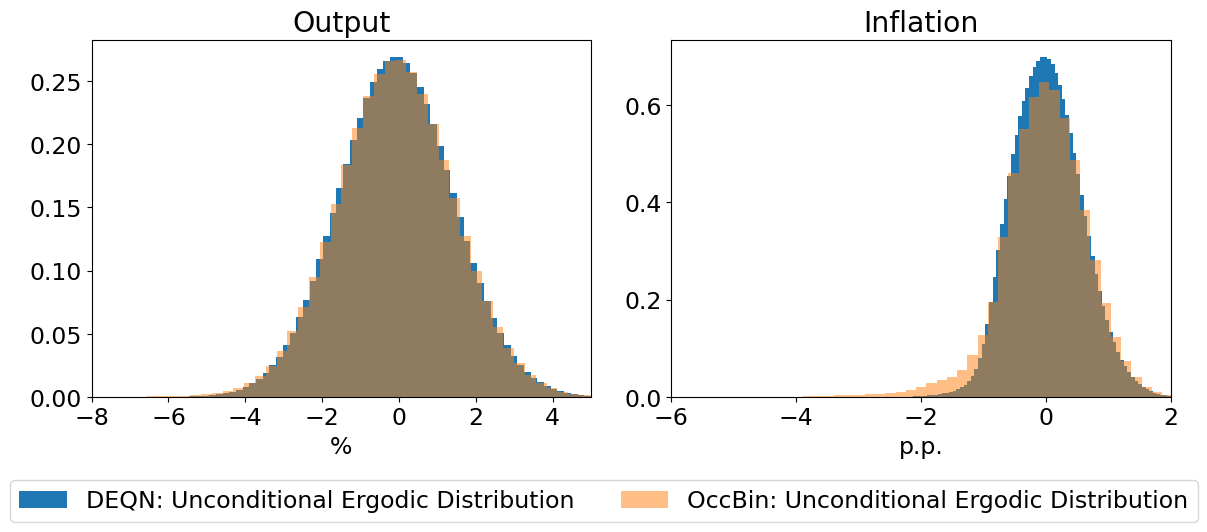

In [ ]:
plt.rcParams.update({'font.size': 17})

f, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True, label='DEQN: Unconditional Ergodic Distribution')
ax[0].hist(100*model.sim.Y_dev_OccBin.flatten(), bins=100, density=True, label='OccBin: Unconditional Ergodic Distribution', alpha=0.5)

ax[1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True)
ax[1].hist(100*model.sim.pi_dev_OccBin.flatten(), bins=100, density=True, alpha=0.5)

# ax[1,0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True)
# ax[1,0].hist(100*model.sim.Y_dev[ZLB_4spell].flatten(), bins=100, density=True, alpha=0.5)
# ax[1,0].hist(100*model.sim.Y_dev_OccBin[ZLB_4spell_OccBin].flatten(), bins=100, density=True, alpha=0.5)

# ax[1,1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True)
# ax[1,1].hist(100*model.sim.pi_dev[ZLB_4spell].flatten(), bins=100, density=True, alpha=0.5)
# ax[1,1].hist(100*model.sim.pi_dev_OccBin[ZLB_4spell_OccBin].flatten(), bins=100, density=True, alpha=0.5)

ax[0].set_xlim([-8, 5])
ax[0].set_xlabel('%')

ax[1].set_xlim([-6, 2])
ax[1].set_xlabel('p.p.')

ax[0].set_title('Output')
ax[1].set_title('Inflation')

f.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncols=2)

f.tight_layout()

In [ ]:
print(100*ZLB_4spell.mean())
print(100*ZLB_4spell_OccBin.mean())

0.915006
1.590824


# Long spells

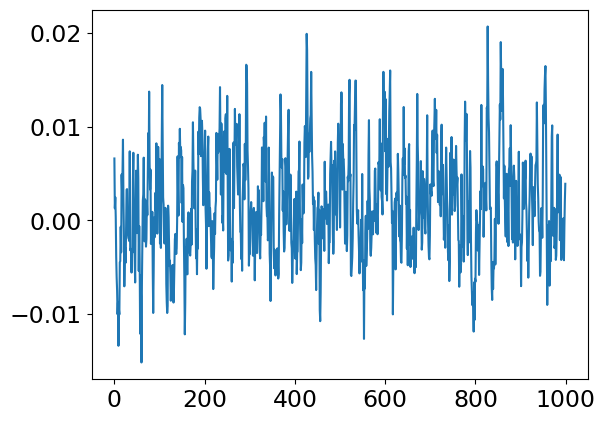

In [ ]:
ZLB_6spell = zlb_min_spell(ZLB_dummies_df, min_spell=6).to_numpy().astype(bool)


plt.plot(model.sim.pi[:1000, 0])

# Simulation ($N=1, T=70$)

In [ ]:
solve.simulate(model, 70, (0.0082, 0.0044, 0.0097), extra_nn=model_noZLB.nn)

NameError: name 'model_noZLB' is not defined

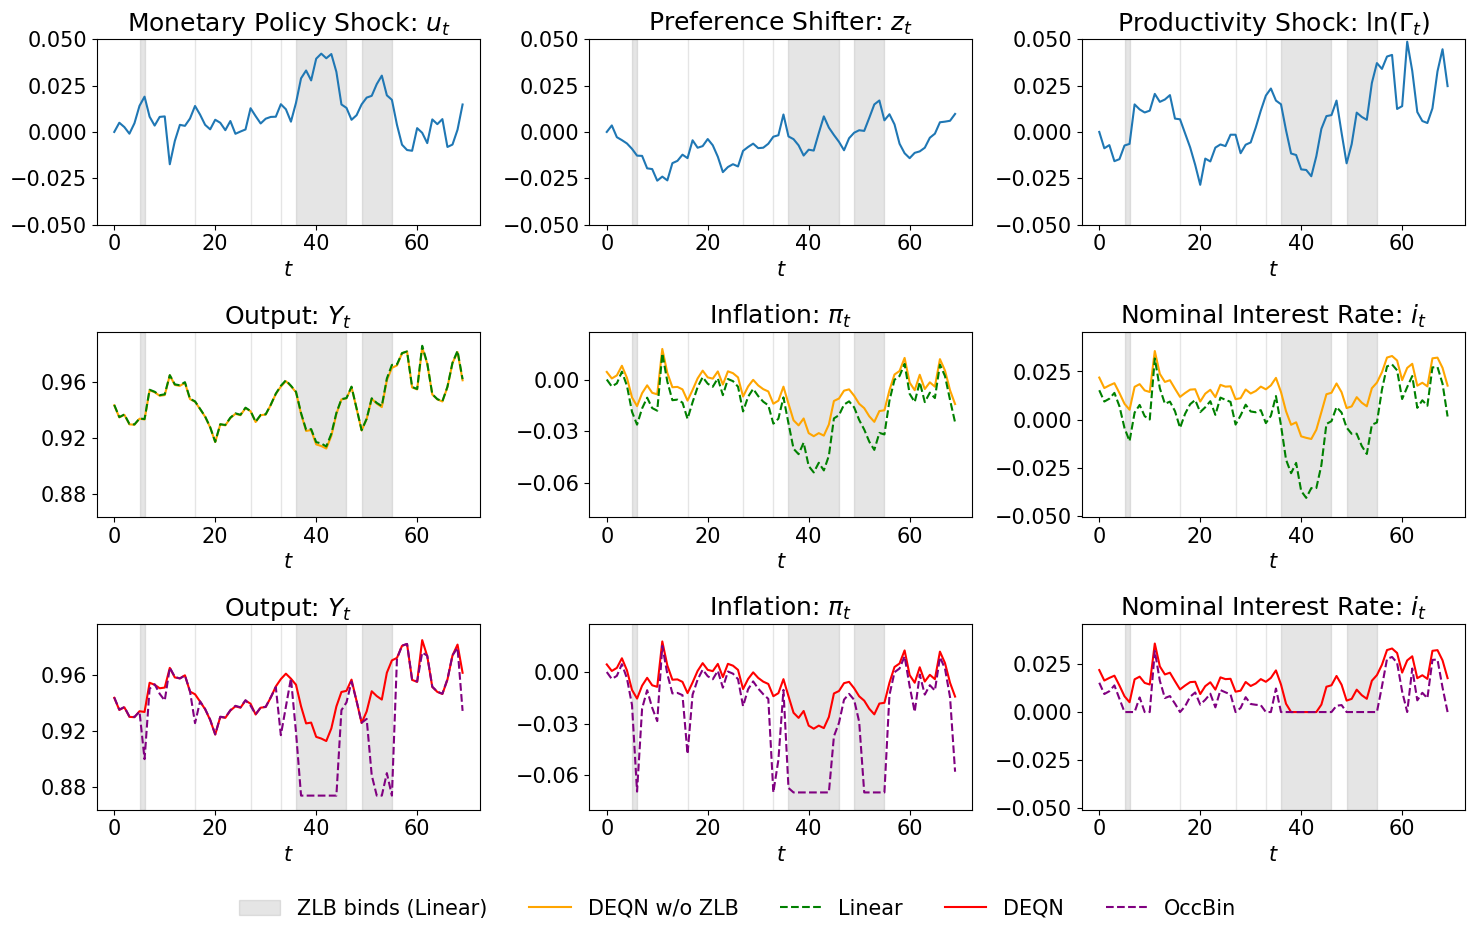

In [ ]:
import matplotlib.ticker as mticker
plt.rcParams.update({'font.size': 15})

f, ax = plt.subplots(3,3, figsize=(15,10))

ax[0,0].plot(model.sim.states[:, 0])
ax[0,0].set_title(r'Monetary Policy Shock: $u_t$')

ax[0,1].plot(model.sim.states[:, 1])
ax[0,1].set_title(r'Preference Shifter: $z_t$')

ax[0,2].plot(model.sim.states[:, 2])
ax[0,2].set_title(r'Productivity Shock: $\ln(\Gamma_t)$')

for i in range(3):
    ax[0,i].set_ylim([-0.05, 0.05])

ax[1,0].plot(model.sim.Y_extra, label='DEQN w/o ZLB', color='orange')
ax[1,0].plot(model.sim.Y_lin, label='Linear', ls = '--', color='green')

ax[1,1].plot(model.sim.pi_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,1].plot(model.sim.pi_lin, ls='--', color='green') #, label='Linear', ls = '--')

ax[1,2].plot(model.sim.i_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,2].plot(model.sim.i_lin, ls='--', color='green') # label='Linear', ls = '--')

ax[2,0].plot(model.sim.Y, label='DEQN', color='red')
ax[2,0].plot(model.sim.Y_OccBin, label='OccBin', ls='--', color='purple')

ax[2,1].plot(model.sim.pi, color='red') #, label='DEQN')
ax[2,1].plot(model.sim.pi_OccBin, ls='--', color='purple') #, label='OccBin', ls='--')

ax[2,2].plot(model.sim.i, color='red') #, label='DEQN')
ax[2,2].plot(model.sim.i_OccBin, ls='--', color='purple') # label='OccBin', ls='--')

#
Ys_ = jnp.stack([model.sim.Y, model.sim.Y_lin, model.sim.Y_extra, model.sim.Y_OccBin])
pis_ = jnp.stack([model.sim.pi, model.sim.pi_lin, model.sim.pi_extra, model.sim.pi_OccBin])
is_ = jnp.stack([model.sim.i, model.sim.i_lin, model.sim.i_extra, model.sim.i_OccBin])

for i in range(1,3):
    ax[i,0].set_ylim([Ys_.min()-0.01, Ys_.max()+0.01])
    ax[i,1].set_ylim([pis_.min()-0.01, pis_.max()+0.01])
    ax[i,2].set_ylim([is_.min()-0.01, is_.max()+0.01])

#
for i in range(3):
    for j in range(1,3):

        ax[j,0].set_title(r'Output: $Y_t$')
        ax[j,1].set_title(r'Inflation: $\pi_t$')
        ax[j,2].set_title(r'Nominal Interest Rate: $i_t$')

zlb_mask = model.sim.i_lin < 0

label_add = True
for i in range(3):
    for j in range(3):
        
        if label_add:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                             ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                             where=zlb_mask, 
                             color='gray', alpha=0.2, label='ZLB binds (Linear)')
            label_add = False

        else:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                        ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                        where=zlb_mask, 
                        color='gray', alpha=0.2)

for i in range(3):
    for j in range(3):
        ax[j,i].set_xlabel('$t$')
        ax[i,j].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4)) # nbins=4 giver præcis 5 ticks

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

f.savefig('plots/Simulation_Example.png')

In [ ]:
model.sim.i_lin.min()

Array(-0.04068768, dtype=float32)

In [ ]:
model.sim.i_extra[41]

Array(-0.00950205, dtype=float32)

# Simulation ($N=10000, T=1$)

In [ ]:
sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

In [ ]:
key = jax.random.key(42)

N = 100_000

states = aux.draw_states_directly(key, model.par, jnp.float32, N, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

Y, pi = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, states, N)
i = model_funcs.taylor_rule(model.par, Y, pi, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

Y_extra, pi_extra = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, states, N)
i_extra = model_funcs.taylor_rule(model.par, Y_extra, pi_extra, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

Y_DSS = model.par["Y_DSS"]
out_OccBin, _ = linear.OccBin(model.par, model.linear, states)
Y_OccBin = jnp.clip(out_OccBin[:, 0], -0.07, 1)
pi_OccBin = jnp.clip(out_OccBin[:, 1], -0.07, 1)
i_OccBin = model_funcs.taylor_rule(model.par, Y_DSS + Y_OccBin, pi_OccBin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

out_lin = states @ model.linear["P"].T
Y_lin = out_lin[:, 0]
pi_lin = out_lin[:, 1]
i_lin = model_funcs.taylor_rule(model.par, Y_DSS + Y_lin, pi_lin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

In [ ]:
print(f'Y\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[Y]\t{jnp.mean(Y_DSS+Y_lin):.4f}\t{jnp.mean(Y_DSS+Y_OccBin):.4f}\t\t{jnp.mean(Y_extra):.4f}\t{jnp.mean(Y):.4f}')
print(f'std[Y]\t{jnp.std(Y_DSS+Y_lin):.4f}\t{jnp.std(Y_DSS+Y_OccBin):.4f}\t\t{jnp.std(Y_extra):.4f}\t{jnp.std(Y):.4f}')
print(f'min[Y]\t{jnp.min(Y_DSS+Y_lin):.4f}\t{jnp.min(Y_DSS+Y_OccBin):.4f}\t\t{jnp.min(Y_extra):.4f}\t{jnp.min(Y):.4f}')
print(f'max[Y]\t{jnp.max(Y_DSS+Y_lin):.4f}\t{jnp.max(Y_DSS+Y_OccBin):.4f}\t\t{jnp.max(Y_extra):.4f}\t{jnp.max(Y):.4f}')

print(f'\npi\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[pi]\t{jnp.mean(pi_lin):.4f}\t{jnp.mean(pi_OccBin):.4f}\t\t{jnp.mean(pi_extra):.4f}\t{jnp.mean(pi):.4f}')
print(f'std[pi]\t{jnp.std(pi_lin):.4f}\t{jnp.std(pi_OccBin):.4f}\t\t{jnp.std(pi_extra):.4f}\t{jnp.std(pi):.4f}')
print(f'min[pi]\t{jnp.min(pi_lin):.4f}\t{jnp.min(pi_OccBin):.4f}\t\t{jnp.min(pi_extra):.4f}\t{jnp.min(pi):.4f}')
print(f'max[pi]\t{jnp.max(pi_lin):.4f}\t{jnp.max(pi_OccBin):.4f}\t\t{jnp.max(pi_extra):.4f}\t{jnp.max(pi):.4f}')

print(f'\ni\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[i]\t{jnp.mean(i_lin):.4f}\t{jnp.mean(i_OccBin):.4f}\t\t{jnp.mean(i_extra):.4f}\t{jnp.mean(i):.4f}')
print(f'std[i]\t{jnp.std(i_lin):.4f}\t{jnp.std(i_OccBin):.4f}\t\t{jnp.std(i_extra):.4f}\t{jnp.std(i):.4f}')
print(f'min[i]\t{jnp.min(i_lin):.4f}\t{jnp.min(i_OccBin):.4f}\t\t{jnp.min(i_extra):.4f}\t{jnp.min(i):.4f}')
print(f'max[i]\t{jnp.max(i_lin):.4f}\t{jnp.max(i_OccBin):.4f}\t\t{jnp.max(i_extra):.4f}\t{jnp.max(i):.4f}')

Y	Linear	OccBin		DEQN-	DEQN
E[Y]	0.9438	0.9347		0.9434	0.9434
std[Y]	0.0134	0.0254		0.0134	0.0134
min[Y]	0.8845	0.8738		0.8845	0.8845
max[Y]	1.0065	1.0065		1.0069	1.0069

pi	Linear	OccBin		DEQN-	DEQN
E[pi]	0.0000	-0.0052		0.0059	0.0059
std[pi]	0.0235	0.0321		0.0195	0.0195
min[pi]	-0.1099	-0.0700		-0.0907	-0.0907
max[pi]	0.1108	0.1108		0.1174	0.1174

i	Linear	OccBin		DEQN-	DEQN
E[i]	0.0148	0.0179		0.0237	0.0237
std[i]	0.0211	0.0167		0.0152	0.0151
min[i]	-0.0907	0.0000		-0.1152	0.0000
max[i]	0.1094	0.1094		0.1215	0.1215


In [ ]:
# En lille hjælpefunktion til at beregne skewness (skævhed)
def skewness(x):
    return jnp.mean(((x - jnp.mean(x)) / jnp.std(x))**3)

# Beregninger for Y
print(f'Y\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[Y]\t{jnp.mean(Y_DSS+Y_lin):.4f}\t{jnp.mean(Y_DSS+Y_OccBin):.4f}\t\t{jnp.mean(Y_extra):.4f}\t{jnp.mean(Y):.4f}')
print(f'std[Y]\t{jnp.std(Y_DSS+Y_lin):.4f}\t{jnp.std(Y_DSS+Y_OccBin):.4f}\t\t{jnp.std(Y_extra):.4f}\t{jnp.std(Y):.4f}')
print(f'med[Y]\t{jnp.median(Y_DSS+Y_lin):.4f}\t{jnp.median(Y_DSS+Y_OccBin):.4f}\t\t{jnp.median(Y_extra):.4f}\t{jnp.median(Y):.4f}')
print(f'ske[Y]\t{skewness(Y_DSS+Y_lin):.4f}\t{skewness(Y_DSS+Y_OccBin):.4f}\t\t{skewness(Y_extra):.4f}\t{skewness(Y):.4f}')

# Beregninger for pi
print(f'\npi\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[pi]\t{jnp.mean(pi_lin):.4f}\t{jnp.mean(pi_OccBin):.4f}\t\t{jnp.mean(pi_extra):.4f}\t{jnp.mean(pi):.4f}')
print(f'std[pi]\t{jnp.std(pi_lin):.4f}\t{jnp.std(pi_OccBin):.4f}\t\t{jnp.std(pi_extra):.4f}\t{jnp.std(pi):.4f}')
print(f'med[pi]\t{jnp.median(pi_lin):.4f}\t{jnp.median(pi_OccBin):.4f}\t\t{jnp.median(pi_extra):.4f}\t{jnp.median(pi):.4f}')
print(f'ske[pi]\t{skewness(pi_lin):.4f}\t{skewness(pi_OccBin):.4f}\t\t{skewness(pi_extra):.4f}\t{skewness(pi):.4f}')

# Beregninger for i
print(f'\ni\tLinear\tOccBin\t\tDEQN-\tDEQN')
print(f'E[i]\t{jnp.mean(i_lin):.4f}\t{jnp.mean(i_OccBin):.4f}\t\t{jnp.mean(i_extra):.4f}\t{jnp.mean(i):.4f}')
print(f'std[i]\t{jnp.std(i_lin):.4f}\t{jnp.std(i_OccBin):.4f}\t\t{jnp.std(i_extra):.4f}\t{jnp.std(i):.4f}')
print(f'med[i]\t{jnp.median(i_lin):.4f}\t{jnp.median(i_OccBin):.4f}\t\t{jnp.median(i_extra):.4f}\t{jnp.median(i):.4f}')
print(f'ske[i]\t{skewness(i_lin):.4f}\t{skewness(i_OccBin):.4f}\t\t{skewness(i_extra):.4f}\t{skewness(i):.4f}')

Y	Linear	OccBin		DEQN-	DEQN
E[Y]	0.9438	0.9347		0.9434	0.9434
std[Y]	0.0134	0.0254		0.0134	0.0134
med[Y]	0.9438	0.9404		0.9434	0.9434
ske[Y]	0.0003	-1.2407		0.0078	0.0078

pi	Linear	OccBin		DEQN-	DEQN
E[pi]	0.0000	-0.0052		0.0059	0.0059
std[pi]	0.0235	0.0321		0.0195	0.0195
med[pi]	0.0000	0.0000		0.0042	0.0042
ske[pi]	0.0054	-0.7032		0.4876	0.4876

i	Linear	OccBin		DEQN-	DEQN
E[i]	0.0148	0.0179		0.0237	0.0237
std[i]	0.0211	0.0167		0.0152	0.0151
med[i]	0.0152	0.0152		0.0214	0.0214
ske[i]	-0.0857	0.7591		0.7757	0.7898


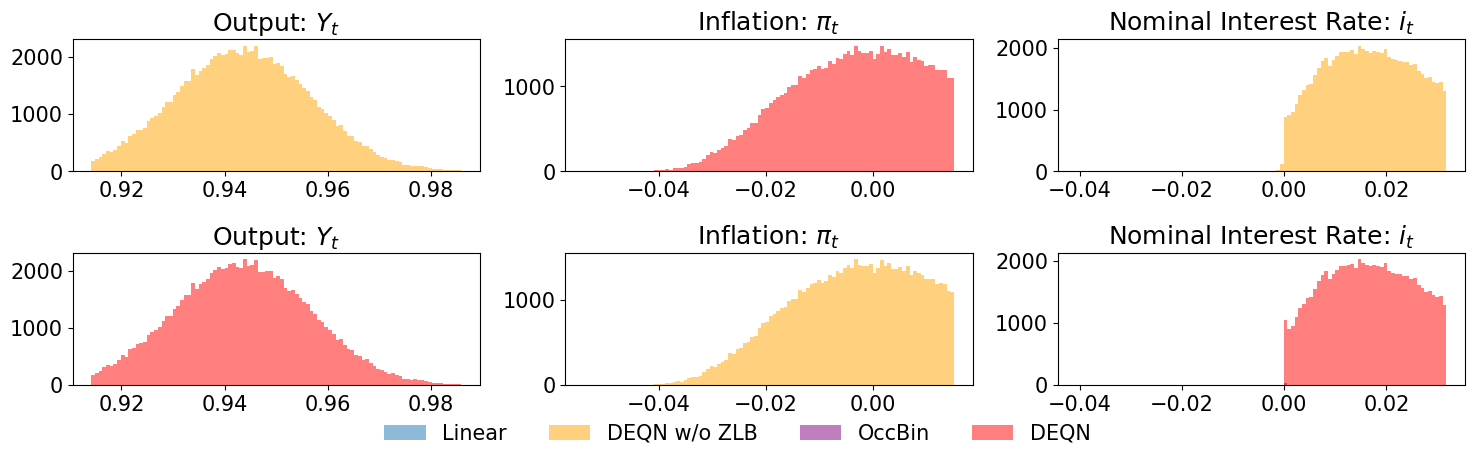

In [ ]:
#maximum observations
data_max = max(model.sim.Y_OccBin.max(), model.sim.Y_lin.max())
sh_bins = np.linspace(model.sim.Y_lin.min(), data_max, 101)

f, ax = plt.subplots(2,3, figsize=(15,5))
ax[0,0].hist(model.sim.Y_lin.flatten(), bins=sh_bins, alpha=0.5, label='Linear')
ax[0,0].hist(Y_extra.flatten(), bins=sh_bins, alpha=0.5, label='DEQN w/o ZLB', color='orange')

ax[1,0].hist(model.sim.Y_OccBin.flatten(), bins=sh_bins, alpha=0.5, label='OccBin', color='purple')
ax[1,0].hist(Y.flatten(), bins=sh_bins, alpha=0.5, label='DEQN', color='red')

data_max = max(model.sim.pi_OccBin.max(), model.sim.pi_lin.max())
sh_bins = np.linspace(model.sim.pi_lin.min(), data_max, 101)

ax[0,1].hist(model.sim.pi_lin.flatten(), bins=sh_bins, alpha=0.5)
ax[1,1].hist(pi_extra.flatten(), bins=sh_bins, alpha=0.5, color='orange')

ax[1,1].hist(model.sim.pi_OccBin.flatten(), bins=sh_bins, alpha=0.5, color='purple')
ax[0,1].hist(pi.flatten(), bins=sh_bins, alpha=0.5, color='red')

data_max = max(model.sim.i_OccBin.max(), model.sim.i_lin.max())
sh_bins = np.linspace(model.sim.i_lin.min(), data_max, 101)

ax[0,2].hist(model.sim.i_lin.flatten(), bins=sh_bins, alpha=0.5)
ax[0,2].hist(i_extra.flatten(), bins=sh_bins, alpha=0.5, color='orange')

ax[1,2].hist(model.sim.i_OccBin.flatten(), bins=sh_bins, alpha=0.5, color='purple')
ax[1,2].hist(i.flatten(), bins=sh_bins, alpha=0.5, color='red')

for i_ in range(2):
    ax[i_,0].set_title(r'Output: $Y_t$')
    ax[i_,1].set_title(r'Inflation: $\pi_t$')
    ax[i_,2].set_title(r'Nominal Interest Rate: $i_t$')

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

# f.savefig('Ergodic_distribution_lin_OccBin.png')

# Simulation ($N=1, T=1000$)

In [ ]:
sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

In [ ]:
key = jax.random.key(42)

T = 100_000

key, subkey = jax.random.split(key)
eps = aux.draw_shocks(subkey, model.dtype, T, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

states = jnp.zeros((T,3)) + jnp.nan

key, subkey = jax.random.split(key)
states_t = aux.draw_states_directly(subkey, model.par, model.dtype, 1, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

for t in range(T):
    s_p = states_t @ model.linear["K"].T + eps[t, :]
    states = states.at[t].set(s_p.flatten())
    states_t = s_p

In [ ]:
Y, pi = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, states, N)
i = model_funcs.taylor_rule(model.par, Y, pi, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

Y_extra, pi_extra = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, states, N)
i_extra = model_funcs.taylor_rule(model.par, Y_extra, pi_extra, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

Y_DSS = model.par["Y_DSS"]
out_OccBin, _ = linear.OccBin(model.par, model.linear, states)
Y_OccBin = jnp.clip(out_OccBin[:, 0], -0.07, 1)
pi_OccBin = jnp.clip(out_OccBin[:, 1], -0.07, 1)
i_OccBin = model_funcs.taylor_rule(model.par, Y_DSS + Y_OccBin, pi_OccBin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

out_lin = states @ model.linear["P"].T
Y_lin = out_lin[:, 0]
pi_lin = out_lin[:, 1]
i_lin = model_funcs.taylor_rule(model.par, Y_DSS + Y_lin, pi_lin, states[:, 0], states[:, 1], states[:, 2], 0.0, 0.0, -100, jnp.ones(1))

In [ ]:
print(f'\t\tLinear\tOccBin\t\tDEQN-\tDEQN')
ac = lambda x: jnp.corrcoef(x[:-1], x[1:])[0,1].item()
print(f'autocorr[Y]\t{ac(Y_DSS+Y_lin):.4f}\t{ac(Y_DSS+Y_OccBin):.4f}\t\t{ac(Y_extra):.4f}\t{ac(Y):.4f}')
print(f'autocorr[pi]\t{ac(pi_lin):.4f}\t{ac(pi_OccBin):.4f}\t\t{ac(pi_extra):.4f}\t{ac(pi):.4f}')
print(f'autocorr[i]\t{ac(i_lin):.4f}\t{ac(i_OccBin):.4f}\t\t{ac(i_extra):.4f}\t{ac(i):.4f}')

		Linear	OccBin		DEQN-	DEQN
autocorr[Y]	0.7645	0.7188		0.7654	0.7654
autocorr[pi]	0.8702	0.8287		0.8686	0.8686
autocorr[i]	0.8632	0.8472		0.8555	0.8556
